<a href="https://colab.research.google.com/github/Hasibur-sun/garbage-classification-deep-learning/blob/Sun's-implementation/aiproject_garbage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download sumn2u/garbage-classification-v2

Saving kaggle (1).json to kaggle (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2
License(s): MIT
100% 1.07G/1.07G [00:31<00:00, 36.3MB/s]



In [ ]:
!unzip "/content/garbage-classification-v2.zip" -d "/content/garbage-classification"

Streaming output truncated to the last 5000 lines.
  inflating: /content/garbage-classification/standardized_384/metal/metal_789.jpg  
  inflating: /content/garbage-classification/standardized_384/metal/metal_79.jpg  
  inflating: /content/garbage-classification/standardized_384/metal/metal_790.jpg  
  inflating: /content/garbage-classification/standardized_384/metal/metal_791.jpg  
  inflating: /content/garbage-classification/standardized_384/metal/metal_792.jpg  
  inflating: /content/garbage-classification/standardized_384/metal/metal_793.jpg  
  inflating: /content/garbage-classification/standardized_384/metal/metal_794.jpg  
  inflating: /content/garbage-classification/standardized_384/metal/metal_795.jpg  
  inflating: /content/garbage-classification/standardized_384/metal/metal_796.jpg  
  inflating: /content/garbage-classification/standardized_384/metal/metal_797.jpg  
  inflating: /content/garbage-classification/standardized_384/metal/metal_798.jpg  
  inflating: /content/garb

/tmp/ipykernel_1986/3421775691.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Category', y='Count', palette='viridis')


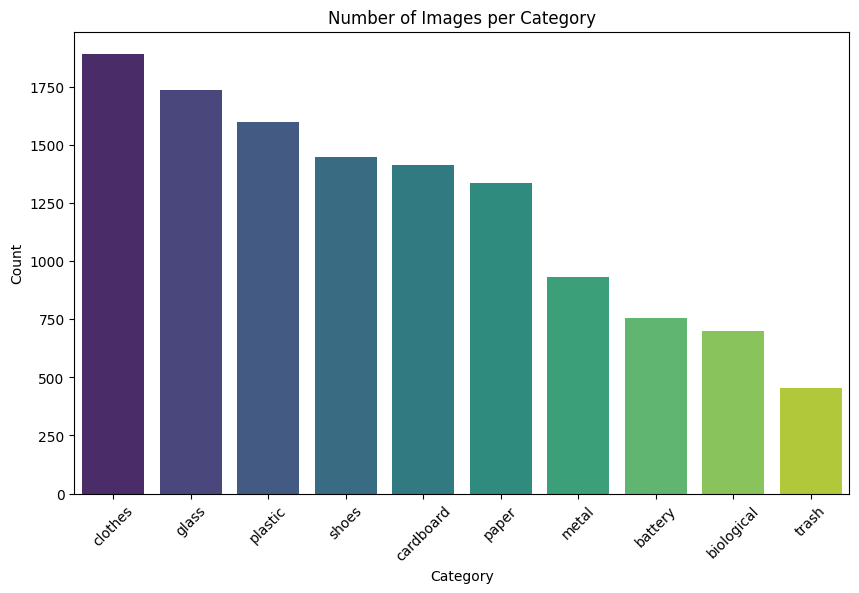

     Category  Count
7     clothes   1892
0       glass   1736
8     plastic   1597
5       shoes   1449
1   cardboard   1411
4       paper   1336
3       metal    930
6     battery    756
2  biological    699
9       trash    453


In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data_dir = '/content/garbage-classification/original'


categories = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

data_counts = []
for cat in categories:
    count = len(os.listdir(os.path.join(data_dir, cat)))
    data_counts.append({'Category': cat, 'Count': count})

df = pd.DataFrame(data_counts).sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Category', y='Count', palette='viridis')
plt.title('Number of Images per Category')
plt.xticks(rotation=45)
plt.show()

print(df)

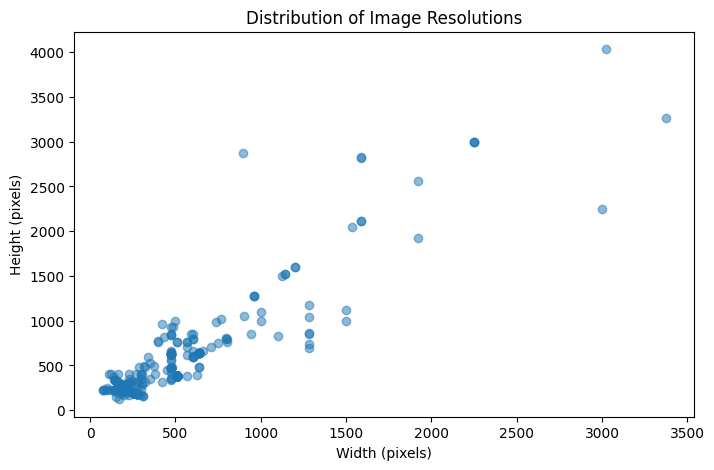

Average Width: 427.72, Average Height: 447.28


In [ ]:
from PIL import Image
import numpy as np

widths = []
heights = []
sample_size = 500

count = 0
for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')) and count < sample_size:
            img = Image.open(os.path.join(root, file))
            w, h = img.size
            widths.append(w)
            heights.append(h)
            count += 1

plt.figure(figsize=(8, 5))
plt.scatter(widths, heights, alpha=0.5)
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.title('Distribution of Image Resolutions')
plt.show()

print(f"Average Width: {np.mean(widths):.2f}, Average Height: {np.mean(heights):.2f}")

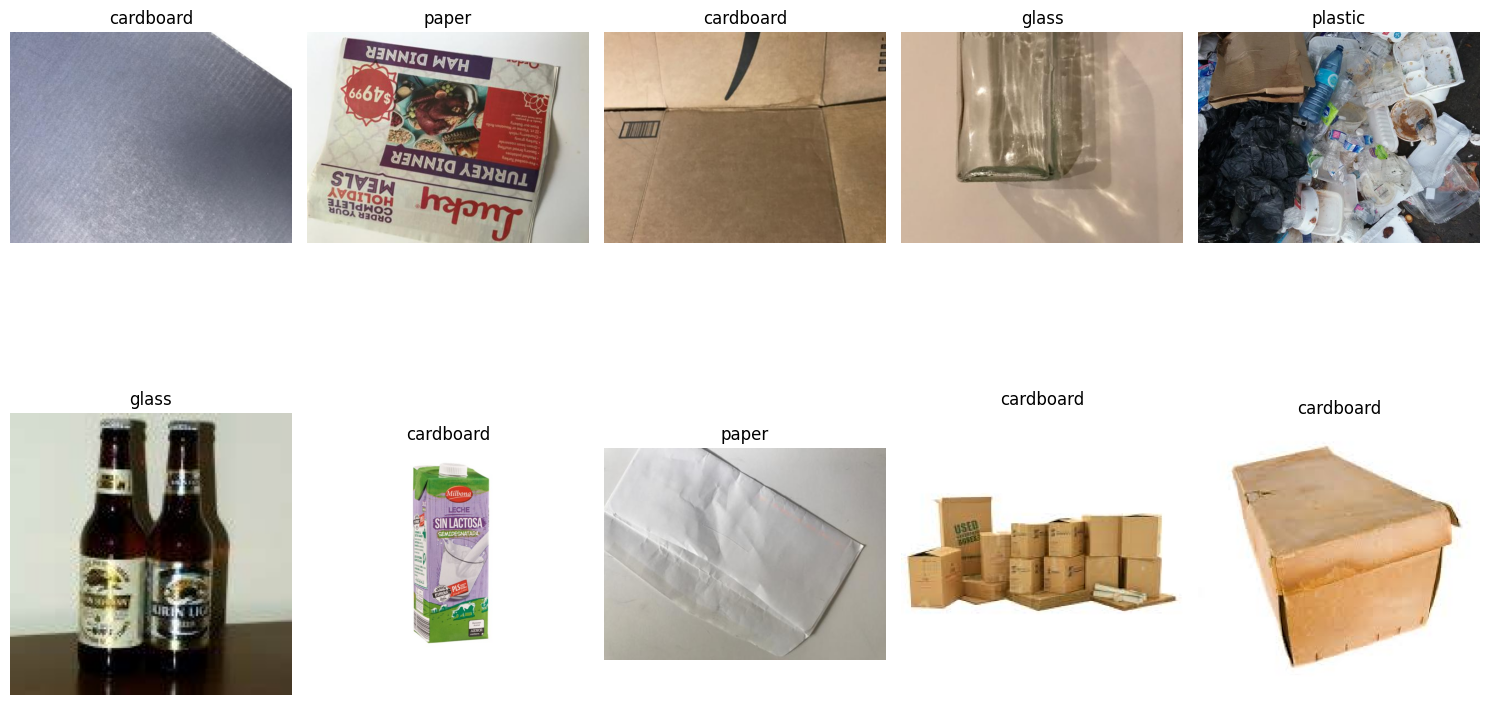

In [ ]:
import random
import matplotlib.image as mpimg

plt.figure(figsize=(15, 10))

all_images = []
for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_images.append(os.path.join(root, file))

sample_images = random.sample(all_images, 10)

for i, img_path in enumerate(sample_images):
    plt.subplot(2, 5, i + 1)
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(os.path.basename(os.path.dirname(img_path)))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def get_color_stats(img_path):
    img = Image.open(img_path).convert('RGB')
    img_np = np.array(img)
    return np.mean(img_np, axis=(0, 1))

color_stats = [get_color_stats(p) for p in random.sample(all_images, 100)]
avg_rgb = np.mean(color_stats, axis=0)

print(f"Average Red intensity: {avg_rgb[0]:.2f}")
print(f"Average Green intensity: {avg_rgb[1]:.2f}")
print(f"Average Blue intensity: {avg_rgb[2]:.2f}")

Average Red intensity: 165.44
Average Green intensity: 155.60
Average Blue intensity: 142.15


cleaning


In [ ]:
import os
from PIL import Image

data_dir = '/content/garbage_data'

def clean_dataset(path):
    for root, dirs, files in os.walk(path):
        for file in files:
            if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                os.remove(os.path.join(root, file))
                continue

            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except (IOError, SyntaxError) as e:
                print(f'Deleting corrupted image: {file_path}')
                os.remove(file_path)

clean_dataset(data_dir)

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split


data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/garbage-classification/original'

temp_dataset_for_split = datasets.ImageFolder(data_dir)

train_idx, temp_idx = train_test_split(
    list(range(len(temp_dataset_for_split))),
    test_size=0.3,
    random_state=42,
    stratify=temp_dataset_for_split.targets
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=[temp_dataset_for_split.targets[i] for i in temp_idx]
)

full_train_dataset_transformed = datasets.ImageFolder(data_dir, transform=data_transforms['train'])
full_val_dataset_transformed = datasets.ImageFolder(data_dir, transform=data_transforms['val'])
full_test_dataset_transformed = datasets.ImageFolder(data_dir, transform=data_transforms['val'])

train_data = Subset(full_train_dataset_transformed, train_idx)
val_data = Subset(full_val_dataset_transformed, val_idx)
test_data = Subset(full_test_dataset_transformed, test_idx)

class_names = temp_dataset_for_split.classes


print(f"Total images: {len(temp_dataset_for_split)}")
print(f"Train (70%): {len(train_data)}")
print(f"Validation (15%): {len(val_data)}")
print(f"Test (15%): {len(test_data)}")

Total images: 12259
Train (70%): 8581
Validation (15%): 1839
Test (15%): 1839


In [ ]:
from torch.utils.data import DataLoader

batch_size = 16
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

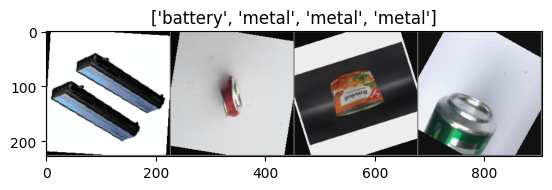

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

inputs, classes = next(iter(train_loader))

import torchvision
out = torchvision.utils.make_grid(inputs[:4])

imshow(out, title=[class_names[x] for x in classes[:4]])

In [ ]:
from torchvision import models

all_models = models.list_models()
print(f"Total models available: {len(all_models)}")

popular_models = [m for m in all_models if "resnet" in m or "mobilenet" in m or "efficientnet" in m]
print("Popular choices for your project:")
print(popular_models[:10])

Total models available: 121
Popular choices for your project:
['deeplabv3_mobilenet_v3_large', 'deeplabv3_resnet101', 'deeplabv3_resnet50', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6']


models


In [ ]:
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator


from torchvision.models.detection import fasterrcnn_resnet50_fpn
model_faster_rcnn = fasterrcnn_resnet50_fpn(weights=None, num_classes=10)


!pip install ultralytics
from ultralytics import YOLO


model_yolo = YOLO("yolo11n.yaml")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 8.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
print(next(model_faster_rcnn.parameters())[0][0][0])

tensor([ 0.0133,  0.0147, -0.0154, -0.0230, -0.0409, -0.0430, -0.0708])


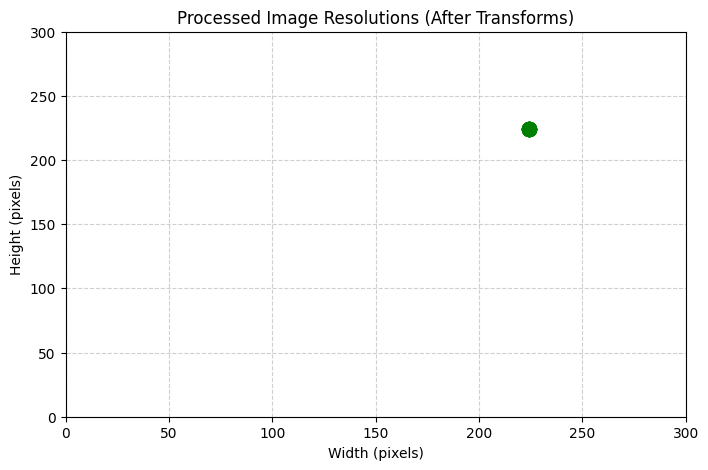

Shape of a single image tensor: torch.Size([3, 224, 224])
Standardized Resolution: 224x224


In [ ]:
import matplotlib.pyplot as plt


images, labels = next(iter(train_loader))

batch_heights = [images.shape[2]] * len(images)
batch_widths = [images.shape[3]] * len(images)

plt.figure(figsize=(8, 5))
plt.scatter(batch_widths, batch_heights, color='green', s=100)
plt.xlim(0, 300)
plt.ylim(0, 300)
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.title('Processed Image Resolutions (After Transforms)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Shape of a single image tensor: {images[0].shape}")
print(f"Standardized Resolution: {images.shape[3]}x{images.shape[2]}")

In [ ]:
type(temp_dataset_for_split)

torchvision.datasets.folder.ImageFolder

model train

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

model_eff_b6 = models.efficientnet_b6(weights='IMAGENET1K_V1')
num_ftrs_b6 = model_eff_b6.classifier[1].in_features
model_eff_b6.classifier[1] = nn.Linear(num_ftrs_b6, 10)

model_efficientnet = models.efficientnet_b2(weights='IMAGENET1K_V1')
num_ftrs_eff = model_efficientnet.classifier[1].in_features
model_efficientnet.classifier[1] = nn.Linear(num_ftrs_eff, 10)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model_simple = SimpleCNN()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
def train_model(model, criterion, optimizer, num_epochs=5):
    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch {epoch}/{num_epochs - 1} Loss: {epoch_loss:.4f}')

criterion = nn.CrossEntropyLoss()

print('--- Training EfficientNet-B6 ---')
optimizer_b6 = optim.Adam(model_eff_b6.parameters(), lr=0.001)
train_model(model_eff_b6, criterion, optimizer_b6, num_epochs=3)

print('\n--- Training EfficientNet-B2 ---')
optimizer_eff = optim.Adam(model_efficientnet.parameters(), lr=0.001)
train_model(model_efficientnet, criterion, optimizer_eff, num_epochs=3)

print('\n--- Training Custom CNN ---')
optimizer_sim = optim.Adam(model_simple.parameters(), lr=0.001)
train_model(model_simple, criterion, optimizer_sim, num_epochs=3)

--- Training EfficientNet-B6 ---
Epoch 0/2 Loss: 0.9178
Epoch 1/2 Loss: 0.6118
Epoch 2/2 Loss: 0.4907

--- Training EfficientNet-B2 ---
Epoch 0/2 Loss: 0.8673
Epoch 1/2 Loss: 0.5769
Epoch 2/2 Loss: 0.4889

--- Training Custom CNN ---
Epoch 0/2 Loss: 2.0393
Epoch 1/2 Loss: 1.8936
Epoch 2/2 Loss: 1.8167
